<a href="https://colab.research.google.com/github/RizkiHadiono/PCVK_Ganjil_25-26/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Mengakses gambar dengan fungsi upload file
from google.colab import files
uploaded = files.upload()

Saving KTM.jpeg to KTM (1).jpeg


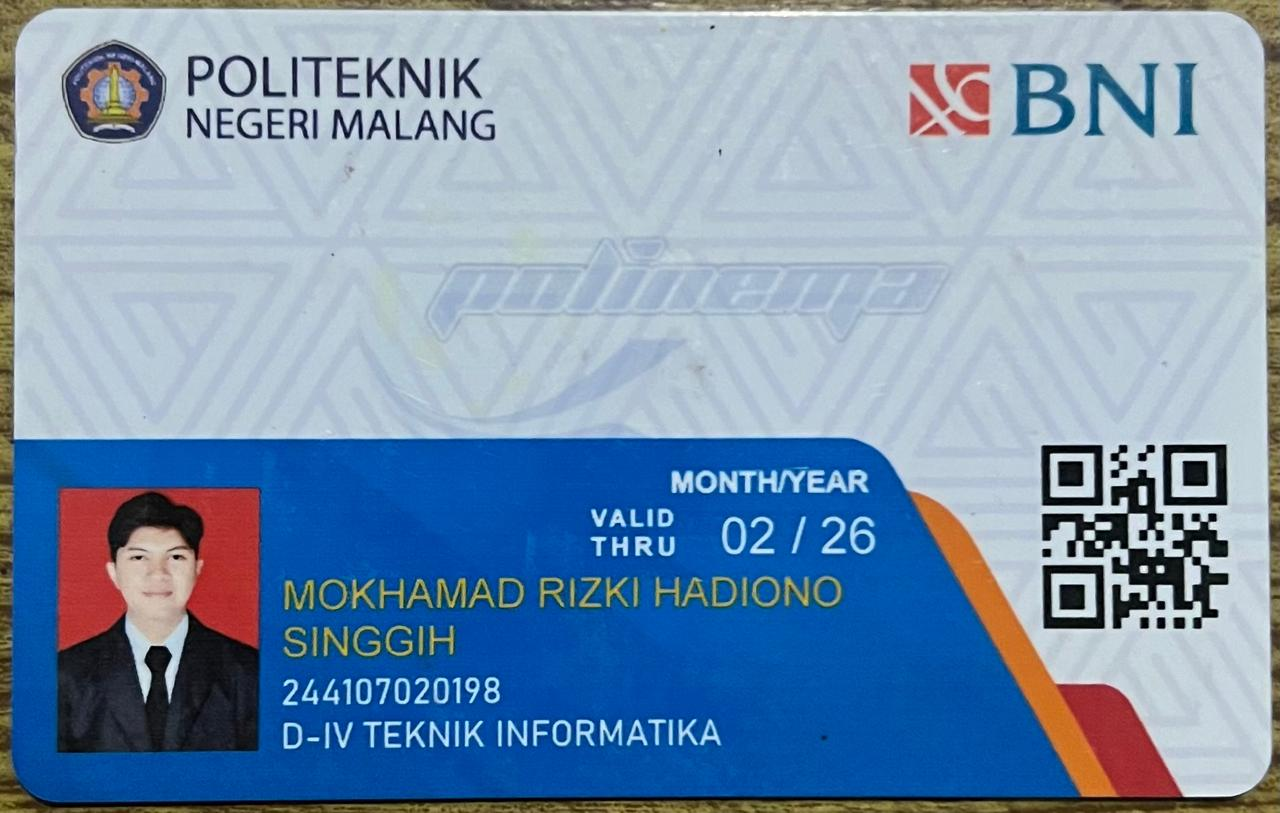

Resolusi gambar:  1280 x 813


In [6]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('KTM.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

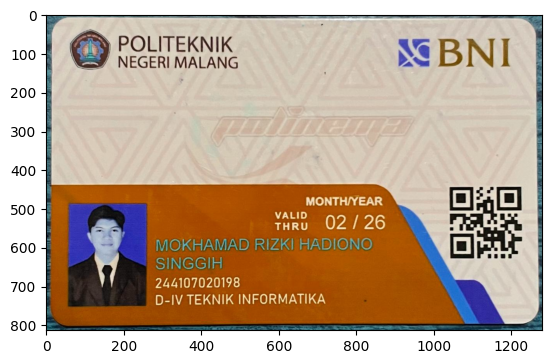

In [7]:
img = cv.imread('KTM.jpeg')
plt.imshow(img) #format warna BGR

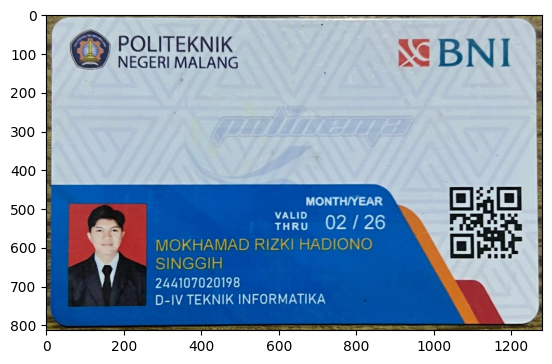

In [9]:
img = cv.imread('KTM.jpeg')
img2 = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi channel BGR RGB
plt.imshow(img2)

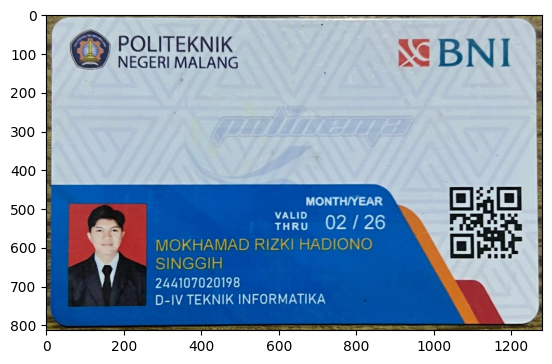

In [10]:
img = cv.imread('KTM.jpeg')
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB)) #konversi channel BGR RGB
plt.show()

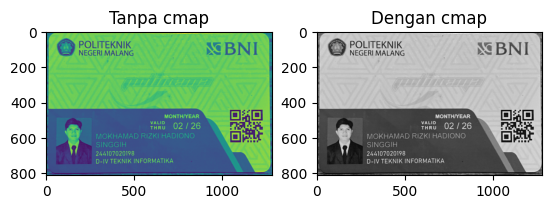

In [12]:
img_gray = cv.imread('KTM.jpeg', cv. IMREAD_GRAYSCALE)

# Tanpa cтар
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cтар
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')
plt.show()

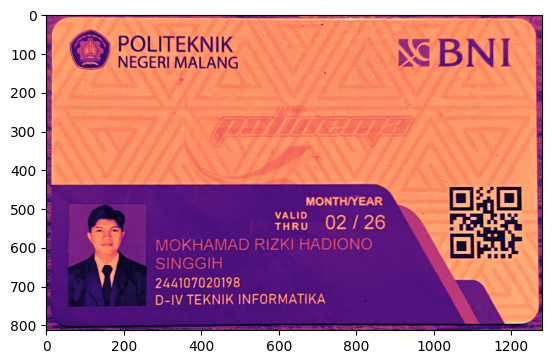

In [13]:
plt.imshow(img_gray, cmap='magma')

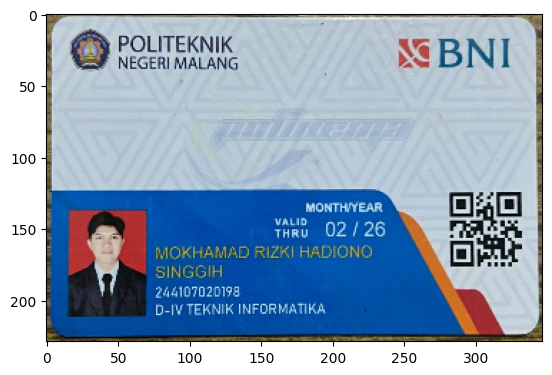

In [14]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

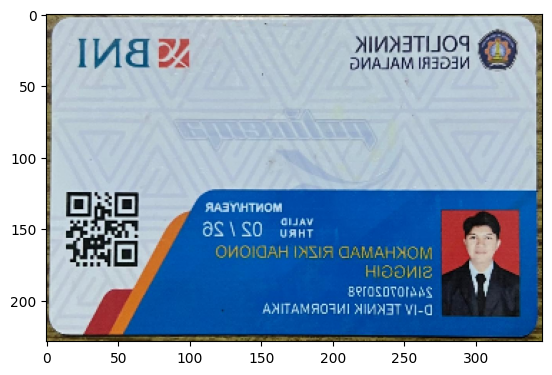

In [15]:
imgFlip=cv.flip(img_output, 1)
plt.imshow(imgFlip)

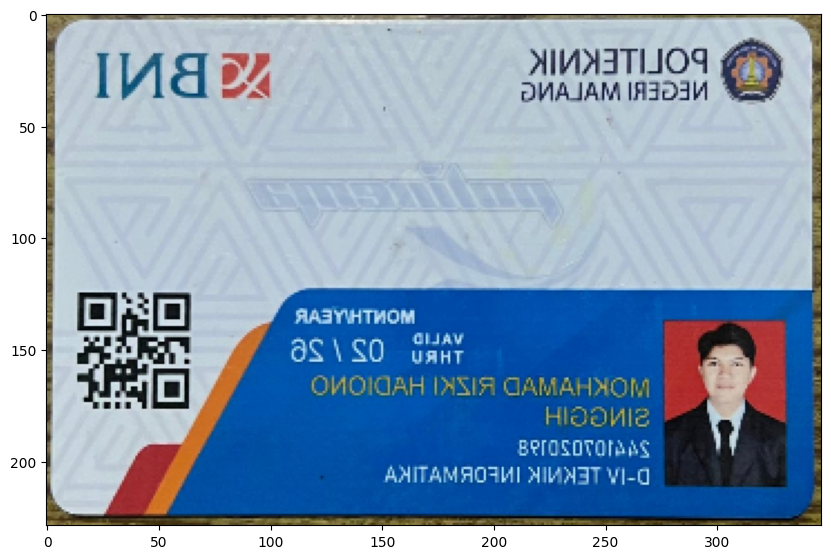

In [16]:
imgFlip=cv.flip(img_output, 1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

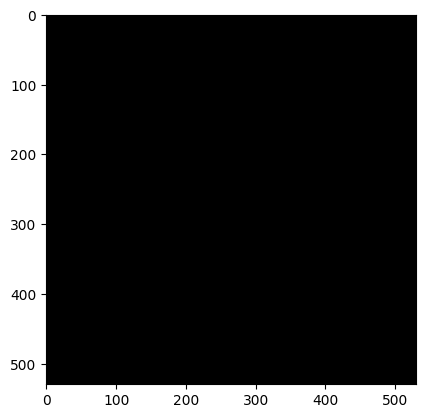

In [17]:
black_img = np.zeros(shape=(530,530,3), dtype=np.int16)
plt.imshow(black_img)

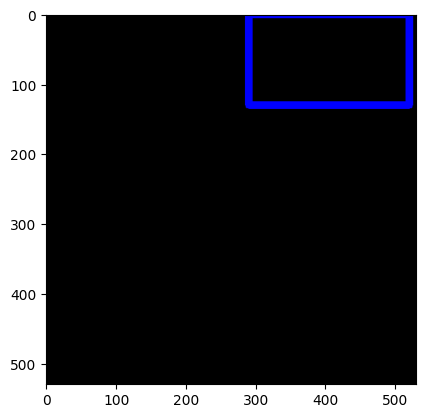

In [19]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0), pt2 = (520, 130) ,color=(0,0,255), thickness=10)
plt.imshow(black_img)

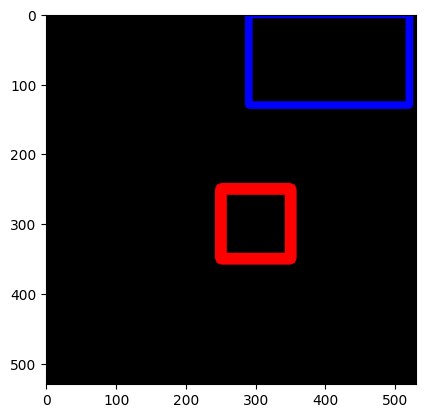

In [22]:
cv.rectangle(black_img,pt1 = (250, 250), pt2 = (350, 350), color=(255,0,0), thickness=15)
plt.imshow(black_img)

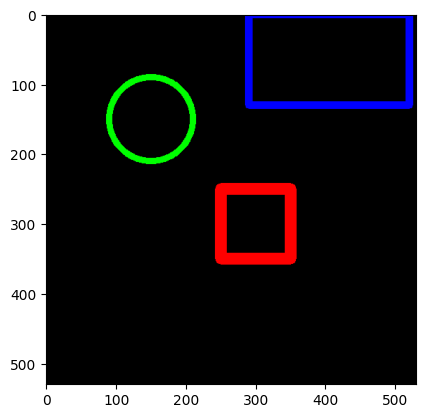

In [23]:
cv.circle(black_img,center=(150, 150), radius=60,color=(0,255,0), thickness=8)
plt.imshow(black_img)

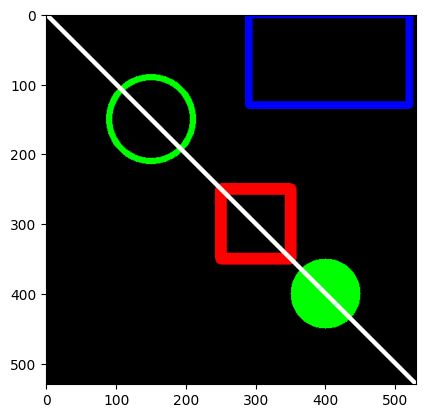

In [26]:
cv.circle(black_img,center=(400,400), radius=50,color=(0,255,0), thickness=-1)
cv.line(black_img, pt1 = (0, 0), pt2 = (530, 530), color=(255,255,255), thickness=5)
plt.imshow(black_img)

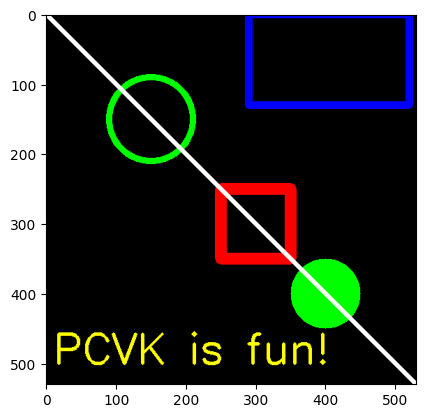

In [27]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
           color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

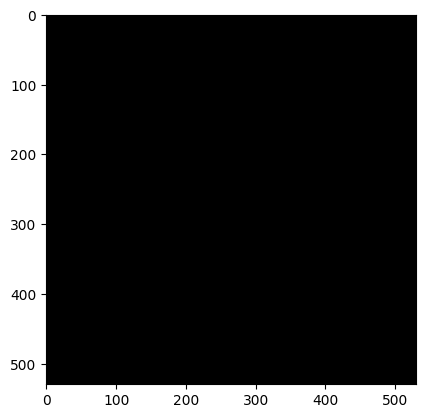

In [28]:
black_img2=np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

In [32]:
vertices = np.array([[150,350], [250,250], [450,350], [250,450]], dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [33]:
pts = vertices.reshape((-1,1,2)) # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

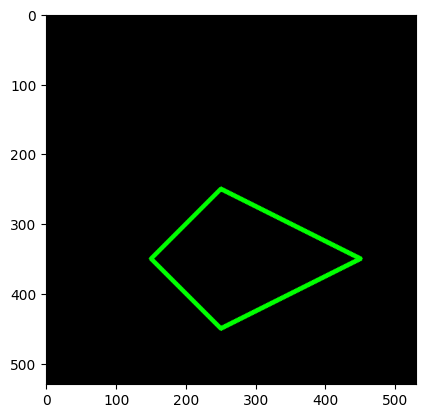

In [34]:
cv.polylines(black_img2, [pts], isClosed=True,color=(0,255,0), thickness=5)
plt.imshow(black_img2)

PERTANYAAN PRAKTIKUM

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

Keluaran berbeda karena cv2.imread() membaca citra dalam urutan kanal BGR, dan fungsi cv2_imshow() juga mengasumsikan masukan dalam format BGR sehingga gambar tampak normal. Sebaliknya, plt.imshow() mengasumsikan bahwa array masukan sudah berurutan RGB. Jika citra BGR dimasukkan ke plt.imshow(), kanal biru (indeks 0) dan merah (indeks 2) akan tertukar posisinya secara visual.

Pembuktian kode:

In [36]:
print("Piksel [0,0] dari cv2 (BGR):", img[0,0])
print("Piksel [0,0] setelah konversi (RGB):", img2[0,0])

Piksel [0,0] dari cv2 (BGR): [ 53  88 101]
Piksel [0,0] setelah konversi (RGB): [101  88  53]


2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

Tampilan visual kedua kanvas hitam tersebut sama persis karena keduanya sama-sama mewakili intensitas warna 0 (hitam). Namun secara struktur memori, terdapat perbedaan:
*   dtype: Kanvas pertama bernilai int16, kanvas kedua bernilai int32.

*   min() dan max() (Rentang Nilai): int16 dapat menampung nilai dari -32.768 hingga 32.767, sedangkan int32 menampung nilai jauh lebih besar dari -2.147.483.648 hingga 2.147.483.647.
*   Ukuran Memori (nbytes): Berbeda secara signifikan. int16 memakai 2 byte per piksel, sedangkan int32 memakai 4 byte per piksel. Sebagai contoh, array 530x530x3 bertipe int16 memiliki memori sebesar 530 * 530 * 3 * 2 = 1.685.400 bytes, sedangkan tipe int32 akan memakan memori dua kali lipatnya, yaitu 3.370.800 bytes.

3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?

Fungsi cv2.imshow() bawaan OpenCV dirancang untuk memanggil jendela antarmuka pengguna (GUI) pada sistem operasi lokal komputer untuk menampilkan gambar. Karena Google Colab berjalan di lingkungan peramban (browser) berbasis cloud, akses ke pustaka GUI OS lokal tidak tersedia. Oleh karena itu, Colab menyediakan patch khusus (cv2_imshow) agar citra dapat dirender dan ditampilkan sebagai keluaran (output) sel di dalam browser.